In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"


In [3]:
from datasets import load_dataset
# reasoning_dataset = load_dataset("unsloth/OpenMathReasoning-mini", split = "cot")
non_reasoning_dataset = load_dataset("mlabonne/FineTome-100k", split = "train")

README.md:   0%|          | 0.00/982 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

In [4]:
from unsloth import FastLanguageModel
model,tokenizer=FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen3-0.6B",
    load_in_4bit=True,
    max_seq_length=2048,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/576M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [5]:
def generate_conversation(examples):
    problems  = examples["problem"]
    solutions = examples["generated_solution"]
    conversations = []
    for problem, solution in zip(problems, solutions):
        conversations.append([
            {"role" : "user",      "content" : problem},
            {"role" : "assistant", "content" : solution},
        ])
    return { "conversations": conversations, }

In [6]:
# reasoning_conversations=tokenizer.apply_chat_template(
#     list(reasoning_dataset.map(generate_conversation,batched=True)["conversations"]),
#     tokenize=False,
# )

In [7]:
# reasoning_conversations_1=reasoning_conversations[:10000]
# reasoning_test=reasoning_conversations[10500:11000]

In [8]:
# reasoning_conversations_1[0]

In [9]:
from unsloth.chat_templates import standardize_sharegpt
non_reasoning_dataset=standardize_sharegpt(non_reasoning_dataset)
non_reasoning_conversations=tokenizer.apply_chat_template(
    list(non_reasoning_dataset["conversations"]),
    tokenize=False,
)

Unsloth: Standardizing formats (num_proc=8):   0%|          | 0/100000 [00:00<?, ? examples/s]

In [10]:
non_reasoning_conversations[0]

'<|im_start|>user\nExplain what boolean operators are, what they do, and provide examples of how they can be used in programming. Additionally, describe the concept of operator precedence and provide examples of how it affects the evaluation of boolean expressions. Discuss the difference between short-circuit evaluation and normal evaluation in boolean expressions and demonstrate their usage in code. \n\nFurthermore, add the requirement that the code must be written in a language that does not support short-circuit evaluation natively, forcing the test taker to implement their own logic for short-circuit evaluation.\n\nFinally, delve into the concept of truthiness and falsiness in programming languages, explaining how it affects the evaluation of boolean expressions. Add the constraint that the test taker must write code that handles cases where truthiness and falsiness are implemented differently across different programming languages.<|im_end|>\n<|im_start|>assistant\n<think>\n\n</th

In [11]:
# import pandas as pd
# data=pd.Series(reasoning_conversations_1)
# data.name="text"

# from datasets import Dataset
# reasoning_conversations_1=Dataset.from_pandas(pd.DataFrame(data))



In [12]:
# import pandas as pd
# data=pd.Series(reasoning_test)
# data.name="text"

# from datasets import Dataset
# reasoning_test=Dataset.from_pandas(pd.DataFrame(data))

In [13]:
non_reasoning_conversations_1=non_reasoning_conversations[:17000]
non_reasoning_conversations_2=non_reasoning_conversations[17000:34000]
non_reasoning_conversations_3=non_reasoning_conversations[34000:51000]
non_reasoning_conversations_full=non_reasoning_conversations[:51000]

In [14]:
from datasets import Dataset

In [15]:
non_reasoning_test=non_reasoning_conversations[90000:90250]

In [16]:
non_reasoning_conversations_1 = Dataset.from_dict({"text": non_reasoning_conversations_1})
non_reasoning_conversations_2 = Dataset.from_dict({"text": non_reasoning_conversations_2})
non_reasoning_conversations_3 = Dataset.from_dict({"text": non_reasoning_conversations_3})
non_reasoning_conversations_full = Dataset.from_dict({"text": non_reasoning_conversations_full})

In [17]:
non_reasoning_test = Dataset.from_dict({"text": non_reasoning_test})

In [18]:
non_reasoning_test[0]

{'text': '<|im_start|>user\nWrite Python code to solve the task:\nGiven a string `S` and a character `C`, return an array of integers representing the shortest distance from the current character in `S` to `C`.\n\n### Notes\n\n* All letters will be lowercase.\n* If the string is empty, return an empty array.\n* If the character is not present, return an empty array.\n\n## Examples\n\n```python\nshortest_to_char("lovecodewars", "e") == [3, 2, 1, 0, 1, 2, 1, 0, 1, 2, 3, 4]\nshortest_to_char("aaaabbbb", "b") == [4, 3, 2, 1, 0, 0, 0, 0]\nshortest_to_char("", "b") == []\nshortest_to_char("abcde", "") == []\n```\n\n___\n\nIf you liked it, please rate  :D<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nStep 1:  This problem requires finding the shortest distance from each character in the given string to a specified character.Step 2:  We can start by checking if the input string is empty or if the specified character is empty, in which case we return an empty array.Step 3:  Next, we 

In [19]:
# len(reasoning_conversations)

In [20]:
non_reasoning_conversations_1[0]

{'text': '<|im_start|>user\nExplain what boolean operators are, what they do, and provide examples of how they can be used in programming. Additionally, describe the concept of operator precedence and provide examples of how it affects the evaluation of boolean expressions. Discuss the difference between short-circuit evaluation and normal evaluation in boolean expressions and demonstrate their usage in code. \n\nFurthermore, add the requirement that the code must be written in a language that does not support short-circuit evaluation natively, forcing the test taker to implement their own logic for short-circuit evaluation.\n\nFinally, delve into the concept of truthiness and falsiness in programming languages, explaining how it affects the evaluation of boolean expressions. Add the constraint that the test taker must write code that handles cases where truthiness and falsiness are implemented differently across different programming languages.<|im_end|>\n<|im_start|>assistant\n<think

In [21]:
# data=pd.Series(reasoning_conversations_1)
# data.name="text"
# reasoning_conversations_1=Dataset.from_pandas(pd.DataFrame(data))

In [22]:
# from datasets import load_dataset, concatenate_datasets

# LABEL_MAP = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

# def stratified_sample(dataset, n_per_class, seed=42):
#     """Sample n_per_class examples from each label, shuffled."""
#     samples = []
#     for label_val in sorted(set(dataset["label"])):
#         subset = dataset.filter(lambda x: x["label"] == label_val)
#         n = min(n_per_class, len(subset))
#         samples.append(subset.shuffle(seed=seed).select(range(n)))
#     return concatenate_datasets(samples).shuffle(seed=seed)


# # ── Load raw AG News ──
# raw_train = load_dataset("fancyzhx/ag_news", split="train")
# raw_test  = load_dataset("fancyzhx/ag_news", split="test")

# # ── Stratified sample: balanced classes ──
# n_train_per_class = 2500   # → 10,000 total train
# n_test_per_class   = 125   # → 500 total test

# train_dataset = stratified_sample(raw_train, n_train_per_class)
# test_dataset  = stratified_sample(raw_test,  n_test_per_class)

# # ── Verify balance ──
# from collections import Counter
# print("Train label distribution:", Counter(train_dataset["label"]))
# print("Test label distribution :", Counter(test_dataset["label"]))


# # ── Format with Qwen chat template ──
# def format_example(example):
#     label_str = LABEL_MAP[example["label"]]
#     messages = [
#         {"role": "user", "content": (
#             f"Classify the text into one of:World,Sports,Business,Sci/Tech \n\n"
#             f"Text:{example['text']}"
#         )},
#         {"role": "assistant", "content": label_str},
#     ]
#     text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
#     return {"text": text}

# train_dataset = train_dataset.map(format_example)
# test_dataset  = test_dataset.map(format_example)

# print(train_dataset[0]["text"])

In [23]:
# train_dataset[0]

In [24]:
# def strip_empty_think(example):
#     example["text"] = example["text"].replace("<think>\n\n</think>\n\n", "")
#     return example

# train_dataset = train_dataset.map(strip_empty_think)
# test_dataset = test_dataset.map(strip_empty_think)

In [25]:
!pip install wandb

In [26]:
import wandb
wandb.login(key=key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rakesrishtik (rakesrishtik-iiitkottayam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [27]:
# type(reasoning_conversations_1)

In [28]:
from trl import SFTTrainer, SFTConfig
import torch
import matplotlib.pyplot as plt

def train_adapter(dataset,test_dataset,output_dir,key):
    wandb.init(
        project=f"{output_dir}",
        name=output_dir,
        config={
            "model": f"{output_dir}",
            "r": 16,
            "lora_alpha": 32,
            "max_steps": 1000,
            "learning_rate": 5e-5,
            "batch_size": 2,
            "gradient_accumulation_steps": 4,
            "warmup_steps": 5,
            "weight_decay": 0.001,
            "lr_scheduler": "linear",
            "max_seq_length": 2048,
        }
    )
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name="unsloth/Qwen3-0.6B",
        max_seq_length=1024,
        load_in_4bit=True,
    )
    model = FastLanguageModel.get_peft_model(
        model,
        r=16,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        lora_alpha=32,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=3407,
        use_rslora=False,
        loftq_config=None,
    )
    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=dataset,
        eval_dataset=test_dataset,
        args=SFTConfig(
            dataset_text_field="text",
            per_device_train_batch_size=2,
            gradient_accumulation_steps=4,
            warmup_steps=30,
            max_steps=2125,
            learning_rate=5e-5,
            logging_steps=5,
            optim="adamw_8bit",
            weight_decay=0.001,
            lr_scheduler_type="linear",
            seed=3407,
            report_to="wandb",       # changed from "none"
            padding_free=False,
            output_dir=output_dir,
            save_strategy="steps",
            save_steps=125,
            save_total_limit=5,
            eval_strategy="steps",
            eval_steps=20,
            max_grad_norm=1.0,
            logging_nan_inf_filter=False,
        )
    )
    from unsloth.chat_templates import train_on_responses_only

    trainer = train_on_responses_only(
        trainer,
        instruction_part="<|im_start|>user\n",
        response_part="<|im_start|>assistant\n",
    )
    trainer.train()
    log_history=trainer.state.log_history
    steps      = [e["step"] for e in log_history if "loss" in e and "eval_loss" not in e]
    losses     = [e["loss"] for e in log_history if "loss" in e and "eval_loss" not in e]
    grad_steps = [e["step"] for e in log_history if "grad_norm" in e]
    grad_norms = [e["grad_norm"] for e in log_history if "grad_norm" in e]
    eval_steps  = [e["step"] for e in log_history if "eval_loss" in e]
    eval_losses = [e["eval_loss"] for e in log_history if "eval_loss" in e]

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(steps, losses, color="steelblue", label="Train Loss")
    if eval_losses:
        ax1.plot(eval_steps, eval_losses, color="red",
                 linestyle="--", marker="o", label="Eval Loss")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"Training Curves — {output_dir}")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(grad_steps, grad_norms, color="darkorange")
    ax2.set_ylabel("Gradient Norm")
    ax2.set_xlabel("Steps")
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f"{output_dir}_curves.png")
    wandb.log({"training_curves": wandb.Image(f"{output_dir}_curves.png")})
    plt.show()
    wandb.finish()

    model.save_pretrained(output_dir)
    model.push_to_hub(f"Srishtik/{output_dir}",token=key)
    tokenizer.push_to_hub(f"Srishtik/{output_dir}",token=key)

In [29]:
# train_adapter(reasoning_conversations_1,reasoning_test,"3-adapter-merge-qwen-3-0.6B-reasoning-openmath-10k")

In [30]:
non_reasoning_conversations_1[0]

{'text': '<|im_start|>user\nExplain what boolean operators are, what they do, and provide examples of how they can be used in programming. Additionally, describe the concept of operator precedence and provide examples of how it affects the evaluation of boolean expressions. Discuss the difference between short-circuit evaluation and normal evaluation in boolean expressions and demonstrate their usage in code. \n\nFurthermore, add the requirement that the code must be written in a language that does not support short-circuit evaluation natively, forcing the test taker to implement their own logic for short-circuit evaluation.\n\nFinally, delve into the concept of truthiness and falsiness in programming languages, explaining how it affects the evaluation of boolean expressions. Add the constraint that the test taker must write code that handles cases where truthiness and falsiness are implemented differently across different programming languages.<|im_end|>\n<|im_start|>assistant\n<think

wandb: setting up run sb642111
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260623_030044-sb642111
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run 3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-3
wandb: ⭐️ View project at https://wandb.ai/rakesrishtik-iiitkottayam/3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-3
wandb: 🚀 View run at https://wandb.ai/rakesrishtik-iiitkottayam/3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-3/runs/sb642111
wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


==((====))==  Unsloth 2026.6.9: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.6.9 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.
/kaggle/working/unsloth_compiled_cache/UnslothSFTTrainer.py:654: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  super().__init__(


...

Filter (num_proc=8):   0%|          | 0/250 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 16,991 | Num Epochs = 2 | Total steps = 2,125
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 10,092,544 of 606,142,464 (1.67% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
20,1.084618,1.120893
40,1.034949,1.041123
60,1.028825,1.016536
80,1.062653,1.004551
100,0.935860,0.995922
120,0.986738,0.990711
140,0.887269,0.984451
160,0.875377,0.981324
180,0.888991,0.977862
200,0.979317,0.975200


Unsloth: Restored added_tokens_decoder metadata in 3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-3/checkpoint-125/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in 3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-3/checkpoint-250/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in 3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-3/checkpoint-375/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in 3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-3/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in 3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-3/checkpoint-625/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in 3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-3/checkpoint-750/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in 3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-3/checkpoint-875/t

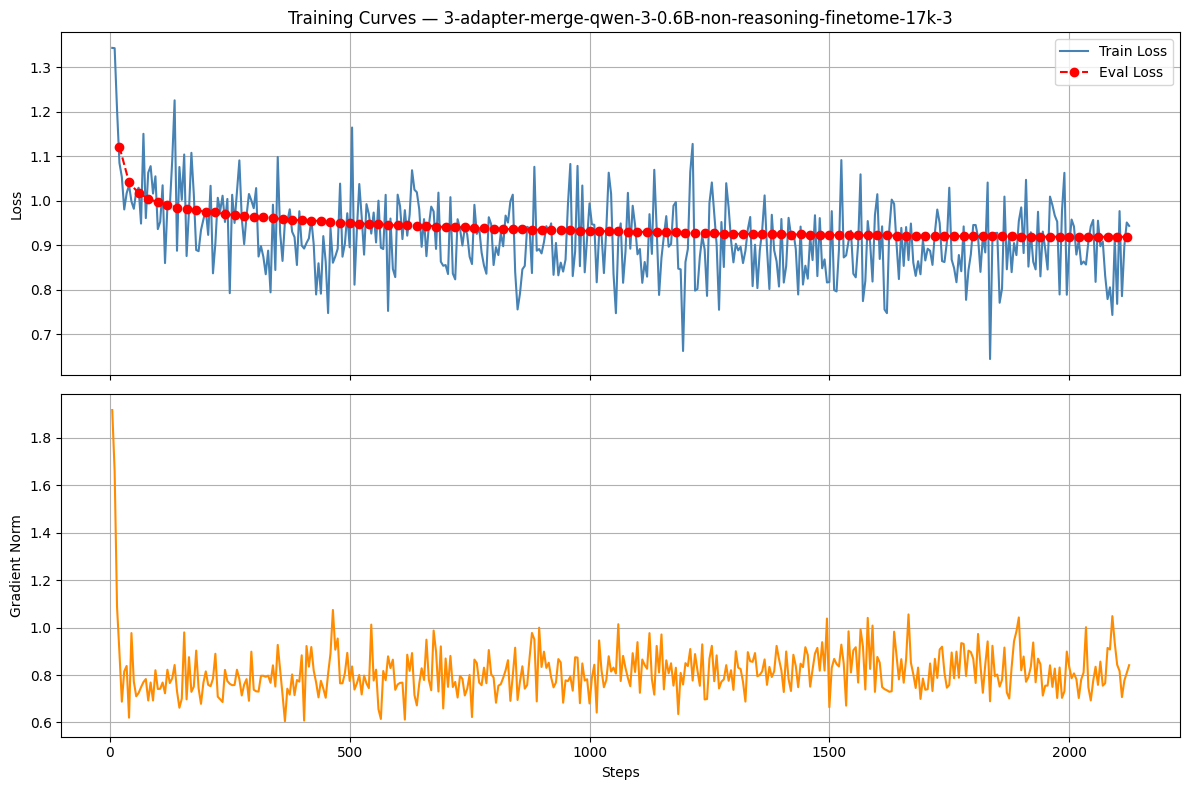

wandb: updating run metadata
wandb: uploading media/images/training_curves_532_46bf0302094ad5a1111a.png; uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: 
wandb: Run history:
wandb:               eval/loss █▆▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:            eval/runtime ▄▄▃▆▇▆▃▆▆▆▆▆▇▄▄█▂▄▇▇▃█▆▅▅▇▆▇▆▇▃▄▁▁▅▃▃▂▇▃
wandb: eval/samples_per_second ▆▄▆▆▆▄▂▆▆▃▆▅▃▅▂▃▁▇▁▃▂▆▄▂▄▅▆▂▄▄▃▃▂▄▁█▆▄▅▆
wandb:   eval/steps_per_second ▄█▄▃▂▃▂▃▂▂▂▂▂▃▃▁▁▄▃▁▂▃▂▁▃▂▂▂▂▃▂▂▁▁▄▂▃▃▂▂
wandb:             train/epoch ▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇█████
wandb:       train/global_step ▁▁▁▁▁▂▂▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇█
wandb:         train/grad_norm ▅▁▄▄▃▃▄▃▄▄▃▂▅▅▆▄▃▆▅▅▆▆▄▄▄▆▅▇█▇█▃▃▄▇▃▆▃▃▅
wandb:     train/learning_rate ████▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▄▄▄▃▃▃▂▂▂▂▁▁▁
wandb:              train/loss ▅▇▆█▄▅▆▃▂▃▇▆▃▃▃▃▄▆▅▅▄▆▁▄▄▂▃▂▅▂▂▃▅▅▅▇▃▅▄▄
wandb: 
wandb: Run summary:
wandb:               eval/loss 0.91853
wandb:            eval/runtime 26.586
wandb: eval/samples_per_second 9.403
wan

README.md:   0%|          | 0.00/560 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/Srishtik/3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-3


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpb37qrgbq/tokenizer_config.json.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

In [31]:
train_adapter(non_reasoning_conversations_3,non_reasoning_test,"3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-3")

In [32]:
# train_adapter(train_dataset,test_dataset,"3-adapter-merge-qwen-3-0.6B-ag-news-10k")

In [33]:
# train_adapter(non_reasoning_conversations_2,non_reasoning_test,"3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-20k-2")

In [34]:
# train_adapter(non_reasoning_conversations_3,non_reasoning_test,"3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-20k-3")